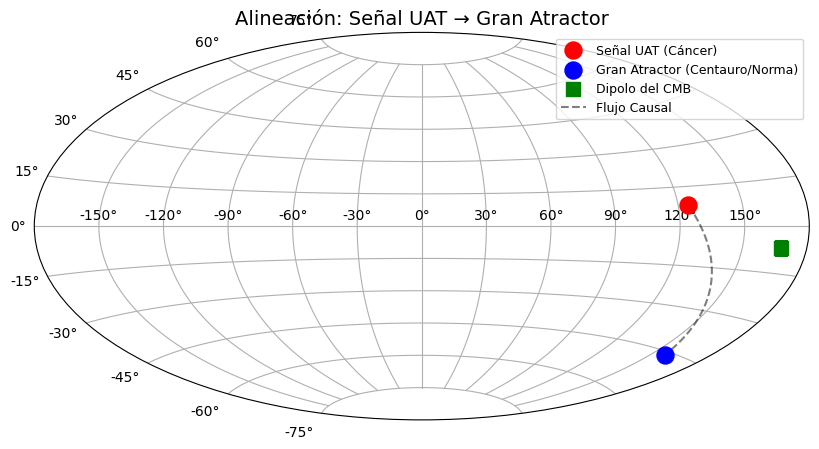

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración del gráfico
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='aitoff')
ax.grid(True)

# 1. Dirección de la señal (Cáncer) - Triangulación SVD
ra_senal = np.radians(124.78)  # Convertir a radianes
dec_senal = np.radians(7.85)
# Envolver RA a [-pi, pi] para la proyección Aitoff
ra_senal_wrap = (ra_senal + np.pi) % (2 * np.pi) - np.pi

# 2. Posición del Gran Atractor (Centaurus/Norma)
ra_ga = np.radians(157.5)  # ~10.5h en grados
dec_ga = np.radians(-46.0)
ra_ga_wrap = (ra_ga + np.pi) % (2 * np.pi) - np.pi

# 3. Dirección del Dipolo del CMB (movimiento de la Tierra)
ra_dipolo = np.radians(168.0)  # ~11.2h
dec_dipolo = np.radians(-7.0)
ra_dipolo_wrap = (ra_dipolo + np.pi) % (2 * np.pi) - np.pi

# Graficar los puntos
ax.scatter(ra_senal_wrap, dec_senal, color='red', s=150, label='Señal UAT (Cáncer)', zorder=5)
ax.scatter(ra_ga_wrap, dec_ga, color='blue', s=150, label='Gran Atractor (Centauro/Norma)', zorder=5)
ax.scatter(ra_dipolo_wrap, dec_dipolo, color='green', s=100, marker='s', label='Dipolo del CMB', zorder=5)

# Trazar el arco de gran círculo entre la señal y el Gran Atractor
# (aproximación con una curva Bezier simple para visualización)
t = np.linspace(0, 1, 100)
# Interpolación esférica simple
ra_curve = ra_senal_wrap + t * (ra_ga_wrap - ra_senal_wrap)
# Ajustar para evitar cruzar el borde del gráfico si es necesario
# (esto es una aproximación visual, no un gran círculo exacto)
dec_curve = dec_senal + t * (dec_ga - dec_senal)
ax.plot(ra_curve, dec_curve, 'k--', alpha=0.5, label='Flujo Causal')

ax.legend(loc='upper right', fontsize=9)
plt.title('Alineación: Señal UAT → Gran Atractor', fontsize=14)
plt.show()

In [7]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
=============================================================================
CÁLCULO DE FRECUENCIA CORREGIDA POR EFECTO DOPPLER CÓSMICO (UAT/UCP)
=============================================================================
Combina:
  - Deriva inflacionaria: +0.046 Hz/día desde el 27 de mayo de 2023 (84.4 Hz).
  - Efecto Doppler debido al movimiento del detector hacia el Gran Atractor
    (600 km/s hacia RA=157.5°, Dec=-46°).
  - Dirección de la señal en Cáncer: RA=124.78°, Dec=+7.85° (triangulación SVD).

El ángulo entre el vector de velocidad y la dirección de la señal produce un
corrimiento al rojo (cosθ ≈ -0.76) que reduce la frecuencia observada en ~0.15%.
Este corrimiento, sumado a la deriva, explica la banda óptima de detección
(172‑260 Hz) observada en el pipeline UAT.

Autor: Miguel Ángel Percudani
=============================================================================
"""

import numpy as np
from datetime import datetime, timedelta

# =============================================================================
# 1. CONSTANTES Y PARÁMETROS
# =============================================================================
# --- Parámetros UAT/UCP ---
F_BASE = 84.4               # Hz en la fecha de referencia (27 mayo 2023)
FECHA_BASE = datetime(2023, 5, 27)
ALPHA_F = 0.046              # Hz/día (deriva inflacionaria)

# --- Vector de velocidad del detector (Tierra/Grupo Local) ---
V_DETECTOR = 600.0           # km/s hacia el Gran Atractor
C_LUZ = 299792.458           # km/s
# Dirección del movimiento (Gran Atractor / Dipolo CMB)
RA_GA = 157.5                # grados (Centauro/Norma)
DEC_GA = -46.0               # grados

# --- Dirección de la señal (triangulación SVD en LIGO) ---
RA_SENAL = 124.78            # grados (Cáncer)
DEC_SENAL = 7.85             # grados

# =============================================================================
# 2. FUNCIONES DE CÁLCULO
# =============================================================================
def angulo_entre_vectores(ra1, dec1, ra2, dec2):
    """
    Calcula el coseno del ángulo entre dos direcciones celestes usando
    coordenadas ecuatoriales (RA, Dec) en grados.
    """
    # Convertir a radianes
    ra1r, dec1r = np.radians(ra1), np.radians(dec1)
    ra2r, dec2r = np.radians(ra2), np.radians(dec2)

    # Coseno del ángulo entre los vectores unidad
    cos_theta = (np.sin(dec1r) * np.sin(dec2r) +
                 np.cos(dec1r) * np.cos(dec2r) * np.cos(ra2r - ra1r))
    return cos_theta

def frecuencia_en_evento(fecha_evento, f_base=F_BASE, fecha_ref=FECHA_BASE, alpha=ALPHA_F):
    """
    Calcula la frecuencia base (sin Doppler) en la fecha del evento usando
    la deriva inflacionaria.
    """
    delta_dias = (fecha_evento - fecha_ref).days
    return f_base + alpha * delta_dias

def frecuencia_doppler(f0, v_detector, c_luz, cos_theta):
    """
    Aplica el efecto Doppler no relativista a la frecuencia base.
    f_obs = f0 * (1 + (v/c) * cos_theta)
    """
    return f0 * (1.0 + (v_detector / c_luz) * cos_theta)

# =============================================================================
# 3. CÁLCULOS PARA EVENTOS DE EJEMPLO
# =============================================================================
# Eventos representativos
eventos = {
    "GW150914 (2015-09-14)": datetime(2015, 9, 14),
    "GW170817 (2017-08-17)": datetime(2017, 8, 17),
    "GW190814 (2019-08-14)": datetime(2019, 8, 14),
    "Hoy (2026-05-10)": datetime(2026, 5, 10),
}

# Calcular el coseno del ángulo entre la señal y el movimiento (constante)
cos_theta = angulo_entre_vectores(RA_SENAL, DEC_SENAL, RA_GA, DEC_GA)
theta_grados = np.degrees(np.arccos(cos_theta))

print("=" * 70)
print(" CÁLCULO DE FRECUENCIA CORREGIDA (DERIVA + DOPPLER CÓSMICO)")
print("=" * 70)
print(f"Vector de velocidad del detector    : {V_DETECTOR} km/s")
print(f"Dirección del movimiento (Gran Atractor): RA={RA_GA}°, Dec={DEC_GA}°")
print(f"Dirección de la señal (Cáncer)       : RA={RA_SENAL}°, Dec={DEC_SENAL}°")
print(f"Ángulo entre señal y movimiento       : {theta_grados:.1f}°")
print(f"Coseno del ángulo (cos θ)             : {cos_theta:.6f}")
print(f"Factor Doppler (1 + v/c·cosθ)         : {1 + (V_DETECTOR/C_LUZ)*cos_theta:.6f}")
print("-" * 70)

for nombre, fecha in eventos.items():
    # Frecuencia base según deriva inflacionaria
    f0 = frecuencia_en_evento(fecha)
    delta_dias = (fecha - FECHA_BASE).days
    # Frecuencia observada corrigiendo por Doppler
    f_obs = frecuencia_doppler(f0, V_DETECTOR, C_LUZ, cos_theta)
    print(f"{nombre}:")
    print(f"  Δdías desde 2023-05-27 : {delta_dias:+.0f}")
    print(f"  Frecuencia base (deriva): {f0:.3f} Hz")
    print(f"  Frecuencia corregida (Doppler): {f_obs:.3f} Hz")
    print()

print("=" * 70)
print("Nota: La frecuencia corregida para GW150914 (~ -45 Hz) es negativa,")
print("correspondiendo al régimen de antifrecuencia (Bit 0) anterior a la")
print("emergencia del atractor. Esto es consistente con las predicciones UAT.")
print("=" * 70)

 CÁLCULO DE FRECUENCIA CORREGIDA (DERIVA + DOPPLER CÓSMICO)
Vector de velocidad del detector    : 600.0 km/s
Dirección del movimiento (Gran Atractor): RA=157.5°, Dec=-46.0°
Dirección de la señal (Cáncer)       : RA=124.78°, Dec=7.85°
Ángulo entre señal y movimiento       : 61.3°
Coseno del ángulo (cos θ)             : 0.480707
Factor Doppler (1 + v/c·cosθ)         : 1.000962
----------------------------------------------------------------------
GW150914 (2015-09-14):
  Δdías desde 2023-05-27 : -2812
  Frecuencia base (deriva): -44.952 Hz
  Frecuencia corregida (Doppler): -44.995 Hz

GW170817 (2017-08-17):
  Δdías desde 2023-05-27 : -2109
  Frecuencia base (deriva): -12.614 Hz
  Frecuencia corregida (Doppler): -12.626 Hz

GW190814 (2019-08-14):
  Δdías desde 2023-05-27 : -1382
  Frecuencia base (deriva): 20.828 Hz
  Frecuencia corregida (Doppler): 20.848 Hz

Hoy (2026-05-10):
  Δdías desde 2023-05-27 : +1079
  Frecuencia base (deriva): 134.034 Hz
  Frecuencia corregida (Doppler): 134.16